# Readme

Plot all functional and retina edge recordings.
Connect the edge recordings to show the outline of the Retina.
Note that the first edge recording is actually the optic disc.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data_folder = "../../data/preprocessed-data"

df_eyewire2_field_level = pd.read_hdf(os.path.join(data_folder, 'df_eyewire2_field_level.h5'), key='dataframe')
df_eyewire2_outline = pd.read_hdf(os.path.join(data_folder, 'df_eyewire2_outline.h5'), key='dataframe')

In [3]:
def plot_stack_average(ax, stack_avg, pixel_size_um, x_offset, y_offset, cmap='viridis', alpha=0.7, gamma=0.5):
    ps = pixel_size_um
    w, h = stack_avg.shape[:2]
    assert w == h
    extent = np.array([-w / 2 * ps, +w / 2 * ps, -w / 2 * ps, +w / 2 * ps])
    extent += (x_offset, x_offset, y_offset, y_offset)

    im = stack_avg.astype(float)
    vmin = np.percentile(im, q=5, axis=(0, 1))
    vmax = np.percentile(im, q=99, axis=(0, 1))
    im = (im - vmin) / (vmax - vmin)
    im = np.clip(im, 0, 1) ** gamma

    ax.imshow(im.T, extent=extent, cmap=cmap, interpolation='none', alpha=alpha)

In [4]:
fig_dir = './figures/responses_by_field'
os.makedirs(fig_dir, exist_ok=True)

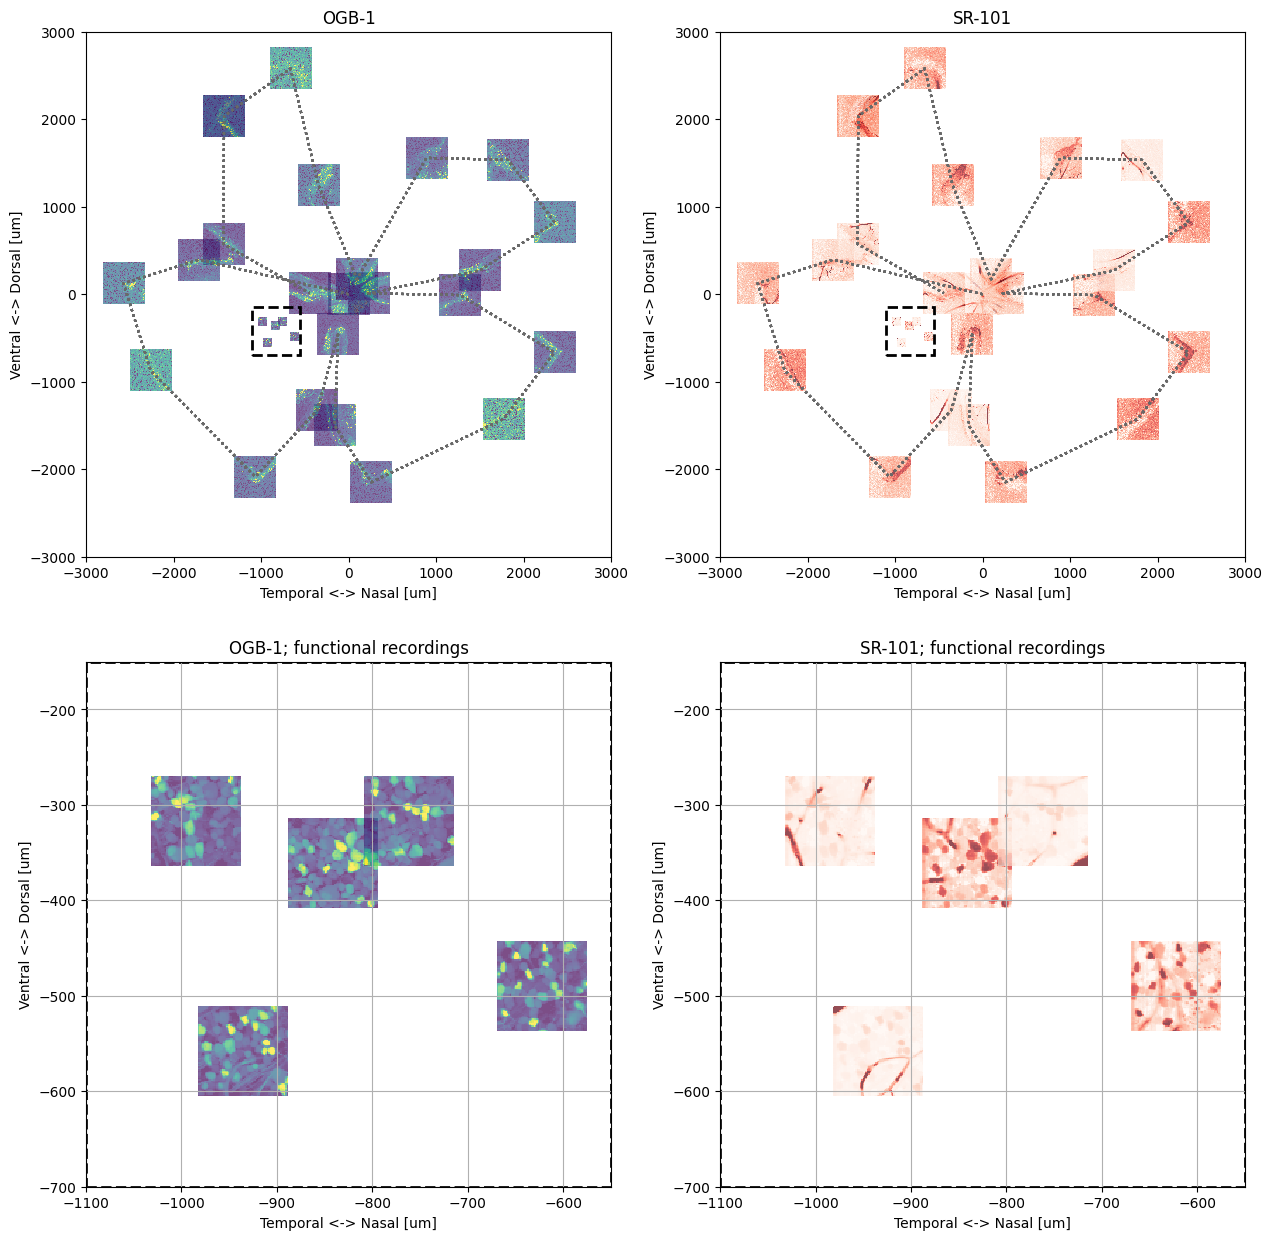

In [5]:
import matplotlib.patches as patches

fig, axs_all = plt.subplots(2, 2, figsize=(15, 15))

axs = axs_all[0, :]
for i, row in df_eyewire2_outline.iterrows():
    for j, ax in enumerate(axs):
        plot_stack_average(ax, row['stack_averages'][:, :, j],
                           row['pixel_size_um'],
                           row['temporal_nasal_pos_um'], row['ventral_dorsal_pos_um'],
                           cmap=['viridis', 'Reds'][j])

    for ax in axs:
        ax.set(xlim=(-3000, 3000), ylim=(-3000, 3000),
               xlabel='Temporal <-> Nasal [um]', ylabel='Ventral <-> Dorsal [um]')
        ax.plot(df_eyewire2_outline['temporal_nasal_pos_um'],
                df_eyewire2_outline['ventral_dorsal_pos_um'], c='dimgray', ls=':')
        ax.grid()
        ax.set_aspect('equal')

for axs in axs_all:
    for i, row in df_eyewire2_field_level.iterrows():
        for j in [0, 1]:
            plot_stack_average(axs[j], row[f'ch{j}_average'],
                               row['pixel_size_um'],
                               row['field_temporal_nasal_pos_um'], row['field_ventral_dorsal_pos_um'],
                               cmap=['viridis', 'Reds'][j])
box_xlim = (-1100, -550)
box_ylim = (-700, -150)
for ax in axs_all[1, :]:
    ax.set(xlim=box_xlim, ylim=box_ylim,
           xlabel='Temporal <-> Nasal [um]', ylabel='Ventral <-> Dorsal [um]')
    ax.grid()
    ax.set_aspect('equal')

for ax in axs_all.flat:
    rect = patches.Rectangle(
        (box_xlim[0], box_ylim[0]), box_xlim[1] - box_xlim[0], box_ylim[1] - box_ylim[0],
        linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)

axs_all[0, 0].set_title('OGB-1')
axs_all[0, 1].set_title('SR-101')

axs_all[1, 0].set_title('OGB-1; functional recordings')
axs_all[1, 1].set_title('SR-101; functional recordings')

plt.savefig(os.path.join(fig_dir, 'retinal_field_locations.pdf'))
plt.show()